In [208]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

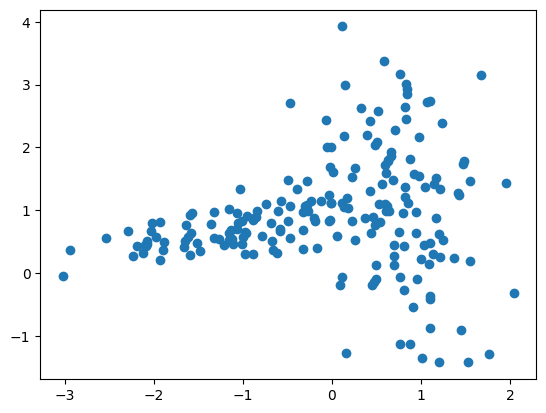

In [209]:

Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

# Initialize K centroids

In [210]:
def init_centroids(X, K, seed=None):
    np.random.seed(seed)
    return X[np.random.choice(X.shape[0], K, replace=False)]

# Compute distances 

In [211]:
def compute_distance(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return distances

# Assign every point to closest centroid

In [212]:
def find_closest_centroids(X, centroids):
    distances = compute_distance(X,centroids)
    return np.argmin(distances, axis=1)

# Compute new centroids 

In [213]:
def compute_new_centroids(X, K, closest_centroids):
    new_centroids = np.zeros((K, X.shape[1]))

    for i in range(K):
        cluster_mask = closest_centroids == i
        cluster_points = X[cluster_mask]

        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(cluster_points, axis=0)
        else:
            new_centroids[i] = X[np.random.choice(X.shape[0])]

    return new_centroids

# Compute Cost

In [214]:
def J(X, centroids, closest_centroids):
    all_distances = []
    
    for c_index in set(closest_centroids):
        mask = closest_centroids == c_index
        assigned_samples = X[mask]
        
        distances_to_centroid = compute_distance(assigned_samples, [centroids[c_index]])
        all_distances.append(np.sum(distances_to_centroid ** 2))
    
    m = X.shape[0] 
    return (1/m) * np.sum(all_distances)

# Implement main K-means algorithm

In [215]:
def kmeans(X, K, max_iterations=100, seed=None):
    centroids = init_centroids(X, K, seed)
    cost_history = []
    
    for iteration in range(max_iterations):
        closest_centroids = find_closest_centroids(X, centroids)
        
        cost = J(X, centroids, closest_centroids)
        cost_history.append(cost)
        
        if iteration > 0 and abs(cost_history[-1] - cost_history[-2]) < 1e-6:
            break
        
        centroids = compute_new_centroids(X, K, closest_centroids)
    
    return centroids, closest_centroids, cost_history

# Multiple runs of K-means

In [216]:
def kmeans_multiple_runs(X, K, num_runs=100, max_iterations=100, seed=None):

    if seed is not None:
        np.random.seed(seed)

    best_cost = float('inf')
    best_centroids = None
    best_assignments = None
    best_cost_history = None
    
    for run in range(num_runs):
        centroids, assignments, cost_history = kmeans(X, K, max_iterations)
        final_cost = cost_history[-1]
        
        if final_cost < best_cost:
            best_cost = final_cost
            best_centroids = centroids
            best_assignments = assignments
            best_cost_history = cost_history
    
    return best_centroids, best_assignments, best_cost_history, best_cost

# Visualization of clusters

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15896\1667803073.py:7: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=150, edgecolors='black')


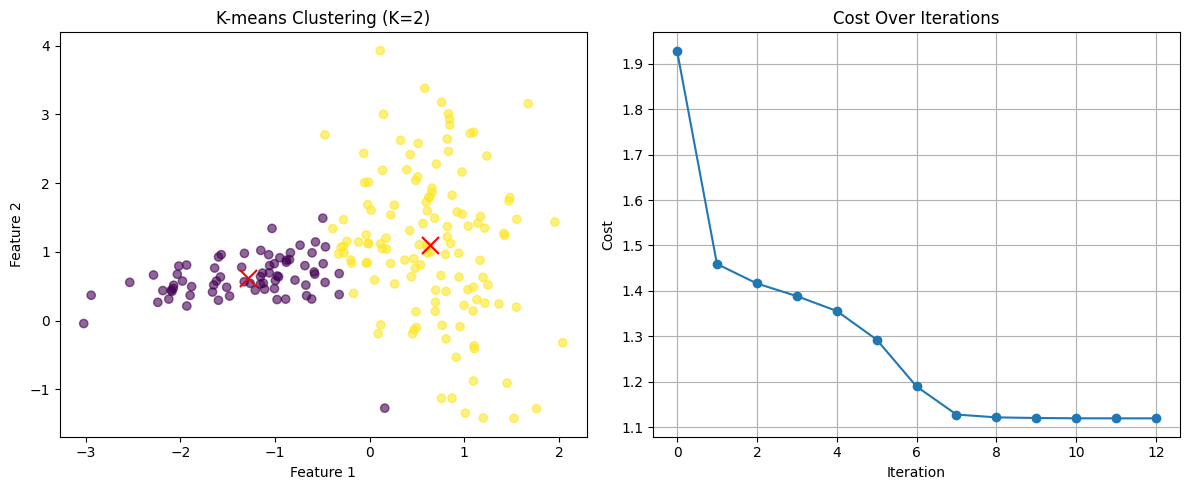

Best cost: 1.1198539724072396


In [219]:

K = 2
centroids, assignments, cost_history, best_cost = kmeans_multiple_runs(Xc_2, K, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Xc_2[:, 0], Xc_2[:, 1], c=assignments, cmap='viridis', alpha=0.6)
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=150, edgecolors='black')
axes[0].set_title(f'K-means Clustering (K={K})')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].plot(cost_history, marker='o')
axes[1].set_title('Cost Over Iterations')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best cost: {best_cost}")

# Elbow method

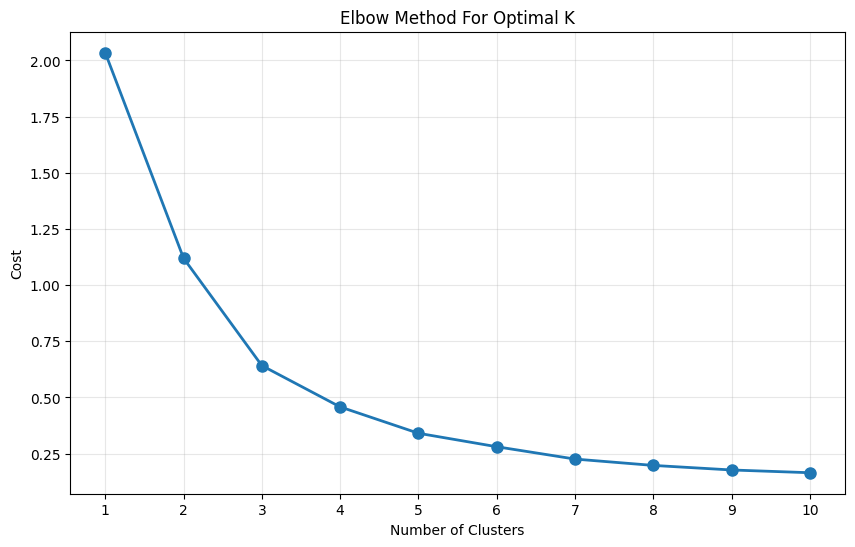

K=1: Cost=2.0346
K=2: Cost=1.1199
K=3: Cost=0.6417
K=4: Cost=0.4577
K=5: Cost=0.3403
K=6: Cost=0.2804
K=7: Cost=0.2254
K=8: Cost=0.1971
K=9: Cost=0.1768
K=10: Cost=0.1646


In [218]:
K_val = range(1, 11)
costs = []

for K in K_val:
    centroids, assignments, cost_history, best_cost = kmeans_multiple_runs(Xc_2, K, num_runs=50, max_iterations=100)
    costs.append(best_cost)

plt.figure(figsize=(10, 6))
plt.plot(K_val, costs, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(K_val)
plt.show()

for K, cost in zip(K_val, costs):
    print(f"K={K}: Cost={cost:.4f}")